In [1]:
import h5py
import os
from lazy5.inspect import get_attrs_dset
import numpy as np
import matplotlib.pyplot as plt
from utils.datagen import create_spend_patches, norm_percentiles,create_spend_dataset_enhanced
from csbdeep.utils import plot_some

In [2]:
DATA_FOLDER = "./data/preprocessed_data"
filename = "preprocessed_medfilter_20250508_celegans_l4_02.h5"
f = h5py.File(os.path.join(DATA_FOLDER,filename), 'r')
# Access the group
preprocessed_group = f['preprocessed_images']

# Print the names of items within the group
print("Items within the 'preprocessed_images' group:")
for key in preprocessed_group.keys():
    print(key)
# Access the 'medfilter_ratio' dataset within the 'preprocessed_images' group
raw_ratio = f['preprocessed_images/medfilter_ratio']

# Print the shape of the extracted dataset
print("Shape of 'medfilter_ratio' dataset:", raw_ratio.shape)
attrs = get_attrs_dset(f, 'preprocessed_images/medfilter_ratio')

Items within the 'preprocessed_images' group:
medfilter_dark
medfilter_nrb_for_ratio
medfilter_ratio
Shape of 'medfilter_ratio' dataset: (320, 500, 2304)


In [3]:
#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe


In [8]:

# Select wn values between 400 and 1800
fast_axis_start = 140
slow_axis_start = 24
ratio = raw_ratio[slow_axis_start:,:,:] # cut off where the stage is not moving
fast_axis_end = fast_axis_start + ratio.shape[0]
wn_mask = (wn >= 400) & (wn <= 3400)
wn_selected = wn[wn_mask]
indices = np.where(wn_mask)[0]
ratio_selected = ratio[:, fast_axis_start:fast_axis_end, indices]
signature_index = 514
point_signal = [97, 170]  # Example point (y, x)
point_noise = [170, 25]  # Example point (y, x)

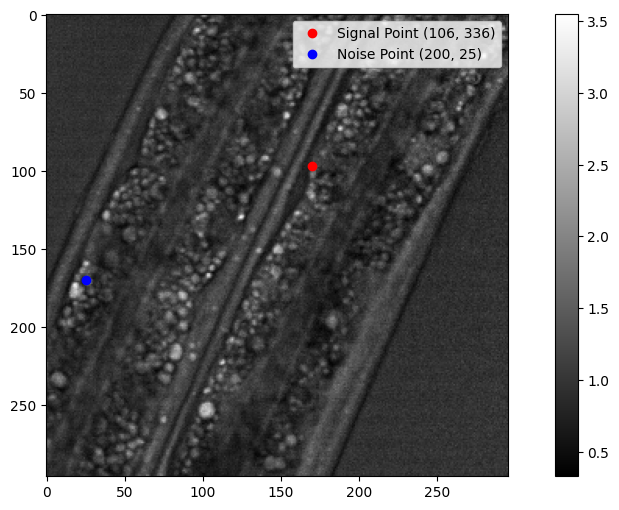

Text(0.5, 1.0, 'Spectra at Selected Points')

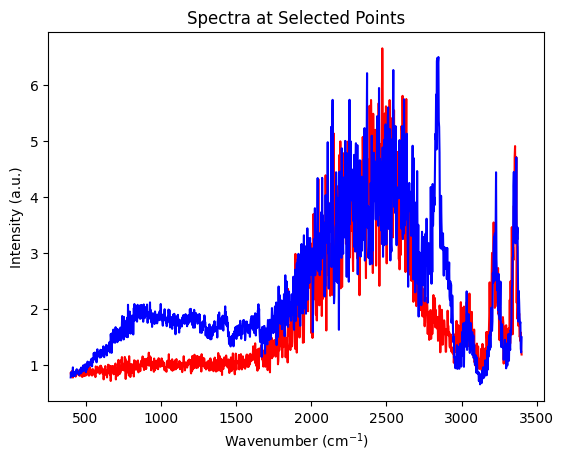

In [9]:
plt.figure(figsize=(12, 6))
plt.imshow(ratio_selected[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()

plt.figure()
plt.plot(wn_selected, ratio_selected[point_signal[0], point_signal[1], :],color="r", label='Signal Point (106, 336)')
plt.plot(wn_selected, ratio_selected[point_noise[0], point_noise[1], :], color="b", label='Noise Point (200, 25)')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Spectra at Selected Points')

In [7]:
print(ratio_selected.shape)

(296, 296, 1345)


In [14]:
from utils.datagen import create_spend_patches, norm_percentiles,create_spend_dataset_enhanced
from csbdeep.utils import plot_some
dataset = create_spend_dataset_enhanced(
    raw=ratio_selected,
    permute_axis="w",
    patch_size=(64, 64, 8),
    normalization=norm_percentiles(percentiles=(1.0, 99.5)),
    verbose=True
)
X,Y = dataset[0]
"""
# Select a specific wavenumber index to visualize 2D XY slices
w_idx = 4  # Middle wavenumber slice (or choose any index from 0 to 7)

for i in range(2):
    plt.figure(figsize=(16,4))
    start_idx = 8*i
    end_idx = 8*(i+1)
    # Make sure we don't exceed the available patches
    end_idx = min(end_idx, X.shape[0])
    
    # Extract 2D XY slices at selected wavenumber
    X_2d = X[start_idx:end_idx, :, :, w_idx]  # Shape: (patches, X, Y)
    Y_2d = Y[start_idx:end_idx, :, :, w_idx]  # Shape: (patches, X, Y)
    
    plot_some(X_2d, Y_2d, title_list=[f"Patch {j}, W={w_idx}" for j in range(start_idx, end_idx)])
    plt.show()
    """

Creating enhanced SPEND dataset:
  Raw shape: (176, 176, 1345)
  Patch size: (64, 64, 8)
  Steps per epoch: 1000
  Normalization: Yes
  Seed: None
Dataset created successfully with 1000 samples per epoch


'\n# Select a specific wavenumber index to visualize 2D XY slices\nw_idx = 4  # Middle wavenumber slice (or choose any index from 0 to 7)\n\nfor i in range(2):\n    plt.figure(figsize=(16,4))\n    start_idx = 8*i\n    end_idx = 8*(i+1)\n    # Make sure we don\'t exceed the available patches\n    end_idx = min(end_idx, X.shape[0])\n\n    # Extract 2D XY slices at selected wavenumber\n    X_2d = X[start_idx:end_idx, :, :, w_idx]  # Shape: (patches, X, Y)\n    Y_2d = Y[start_idx:end_idx, :, :, w_idx]  # Shape: (patches, X, Y)\n\n    plot_some(X_2d, Y_2d, title_list=[f"Patch {j}, W={w_idx}" for j in range(start_idx, end_idx)])\n    plt.show()\n    '

In [15]:
X,Y = create_spend_patches(
    raw=ratio_selected,
    permute_axis = 2,
    patch_size = (32,32,96),
    stride = (16,16,48),
    flip = True,
    rotate=True
)
np.random.seed(15)  # For reproducibility
n_patches = X.shape[0]
shuffle_indices = np.random.permutation(n_patches)

# Shuffle both X and Y with the same indices
X = X[shuffle_indices]
Y = Y[shuffle_indices]

SPEND Preprocessing Pipeline
Raw data shape: (176, 176, 1345)
Patch size: (32, 32, 96)
Permutation axis: 2
Normalization: Yes
Patch filter: No
Generated 2700 patches of shape (32, 32, 96)
X range: [0.000, 1.000]
Y range: [0.000, 1.000]


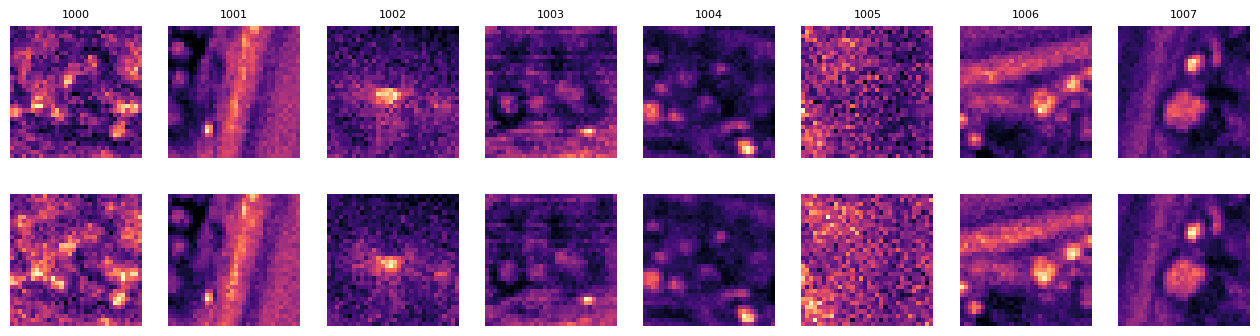

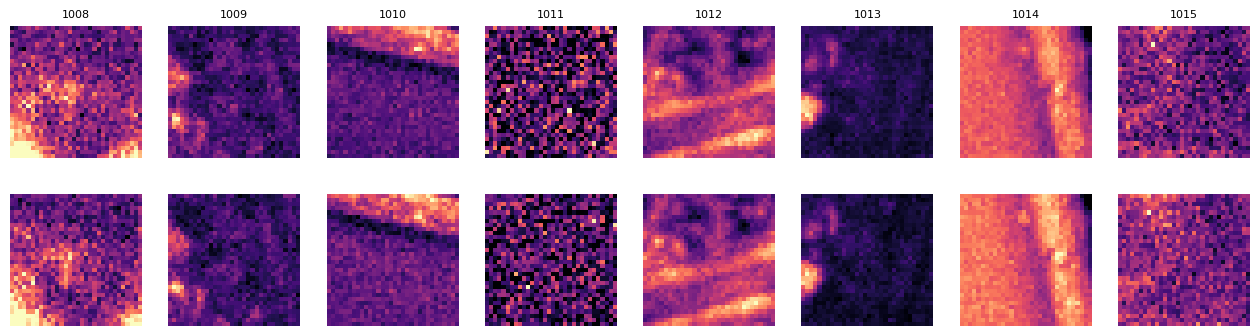

In [16]:
w_idx = 0  # pick a spectral slice

for i in range(2):
    plt.figure(figsize=(16,4))

    # choose samples in groups of 8
    sl = slice(8*i+1000, 8*(i+1)+1000)

    # take X,Y spatial image at fixed wavenumber
    X_sl = X[sl, :, :, w_idx]
    Y_sl = Y[sl, :, :, w_idx]

    plot_some(X_sl, Y_sl,
              title_list=[np.arange(sl.start, sl.stop)])
    plt.show()

In [17]:


# Transpose from (S, Y, X, Z) to (S, Z, Y, X) then add channel dimension
X_transposed = X.transpose(0, 3, 1, 2)  # (S, Y, X, Z) -> (S, Z, Y, X)
Y_transposed = Y.transpose(0, 3, 1, 2)  # (S, Y, X, Z) -> (S, Z, Y, X)

# Add channel dimension: (S, Z, Y, X) -> (S, C, Z, Y, X)
X_with_channel = X_transposed[:, np.newaxis, :, :, :]
Y_with_channel = Y_transposed[:, np.newaxis, :, :, :]

axes = "SCZYX"  # S: samples, C: channels, Z: wavenumber, Y: height, X: width

print(f"Original X shape: {X.shape}")
print(f"Transposed X shape: {X_transposed.shape}")
print(f"Final X shape with channel: {X_with_channel.shape}")
print(f"Axes: {axes}")

# Save as NPZ file with 3 entries
np.savez("patches_data.npz", 
         X=X_with_channel, 
         Y=Y_with_channel, 
         axes=axes)

print("Saved patches_data.npz with shuffled and transposed entries: X, Y, axes")

# Verify the saved file
loaded = np.load("patches_data.npz")
print("NPZ file contents:", list(loaded.keys()))
print("X shape in file:", loaded['X'].shape)
print("Y shape in file:", loaded['Y'].shape)
print("Axes in file:", loaded['axes'])

Original X shape: (2700, 32, 32, 96)
Transposed X shape: (2700, 96, 32, 32)
Final X shape with channel: (2700, 1, 96, 32, 32)
Axes: SCZYX
Saved patches_data.npz with shuffled and transposed entries: X, Y, axes
NPZ file contents: ['X', 'Y', 'axes']
X shape in file: (2700, 1, 96, 32, 32)
Y shape in file: (2700, 1, 96, 32, 32)
Axes in file: SCZYX


In [19]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Build:", tf.sysconfig.get_build_info().get("is_cuda_build"))
print("CUDA:", tf.sysconfig.get_build_info().get("cuda_version"))
print("cuDNN:", tf.sysconfig.get_build_info().get("cudnn_version"))
print("Visible GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.21.0-dev20250916
Build: True
CUDA: 12.5.1
cuDNN: 9
Visible GPUs: []
